In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_path = "dataset/train"
val_path   = "dataset/val"
test_path  = "dataset/test"

# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

# Load data
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1428 images belonging to 4 classes.
Found 736 images belonging to 4 classes.
Found 736 images belonging to 4 classes.


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

In [28]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

In [29]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [30]:
for layer in base_model.layers:
    layer.trainable = False

In [31]:
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [32]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history_mobilenet = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.7836 - loss: 3.5283 - val_accuracy: 0.8628 - val_loss: 0.9837
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8852 - loss: 0.6764 - val_accuracy: 0.8519 - val_loss: 0.7707
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9167 - loss: 0.3998 - val_accuracy: 0.8723 - val_loss: 1.0908
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9027 - loss: 0.5311 - val_accuracy: 0.8370 - val_loss: 1.9413
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9244 - loss: 0.3777 - val_accuracy: 0.9144 - val_loss: 0.5170


In [34]:
model.save("models/mobilenet_model.h5")

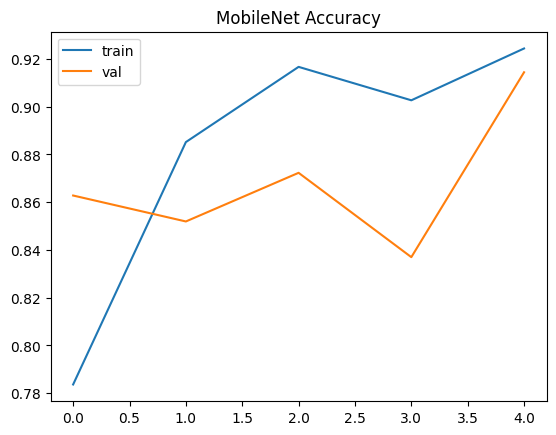

In [35]:
import matplotlib.pyplot as plt

plt.plot(history_mobilenet.history['accuracy'], label='train')
plt.plot(history_mobilenet.history['val_accuracy'], label='val')
plt.legend()
plt.title("MobileNet Accuracy")
plt.show()